In [11]:
%pip install mediapipe opencv-python pandas matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import cv2
import mediapipe as mp
import os
import pandas as pd
import matplotlib.pyplot as plt


In [13]:
import urllib.request
import os

url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task"
filename = "face_landmarker_v2_with_blendshapes.task"

print(f"Downloading to: {os.path.abspath(filename)}")
urllib.request.urlretrieve(url, filename)
print("Download complete!")

# Verify it downloaded
if os.path.exists(filename):
    print(f"File size: {os.path.getsize(filename)} bytes")
else:
    print("ERROR: Download failed!")

Download complete!
File size: 3758596 bytes


In [14]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

model_path = 'face_landmarker_v2_with_blendshapes.task'

base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False
)

face_mesh = vision.FaceLandmarker.create_from_options(options)
print("FaceMesh loaded successfully!")

W0000 00:00:1777910321.087866 5071970 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.


FaceMesh loaded successfully!


I0000 00:00:1777910321.353912 5071970 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777910321.361056 5071977 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777910321.370078 5071973 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [15]:
import os
from pathlib import Path
from PIL import Image

# Folder dataset gốc
input_folder = Path("../Photo")

# Folder output PNG
output_folder = Path("../Photo_PNG")
output_folder.mkdir(parents=True, exist_ok=True)

# Các định dạng hỗ trợ
extensions = [".jpg", ".jpeg", ".bmp", ".tiff", ".webp", ".png"]

count = 0

for root, dirs, files in os.walk(input_folder):
    for file in files:
        ext = Path(file).suffix.lower()

        if ext in extensions:
            old_path = Path(root) / file

            # Giữ cấu trúc folder con
            relative_path = old_path.relative_to(input_folder).with_suffix(".png")
            new_path = output_folder / relative_path

            new_path.parent.mkdir(parents=True, exist_ok=True)

            try:
                img = Image.open(old_path).convert("RGB")
                img.save(new_path, "PNG")
                count += 1
                print(f"Converted: {old_path} -> {new_path}")

            except Exception as e:
                print(f"Error {old_path}: {e}")

print(f"\nDone. Total converted: {count}")

Converted: ../Photo/Khanh.png -> ../Photo_PNG/Khanh.png
Converted: ../Photo/Nam.png -> ../Photo_PNG/Nam.png
Converted: ../Photo/Nu.png -> ../Photo_PNG/Nu.png
Converted: ../Photo/ThanhThu.png -> ../Photo_PNG/ThanhThu.png
Converted: ../Photo/Hieu.png -> ../Photo_PNG/Hieu.png

Done. Total converted: 5


I0000 00:00:1777910618.125077 5076985 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 8, prefix = pthread-default
W0000 00:00:1777910618.128466 5076985 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1777910618.252131 5076985 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1777910618.258308 5076988 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777910618.269999 5076994 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


✓ Model loaded successfully


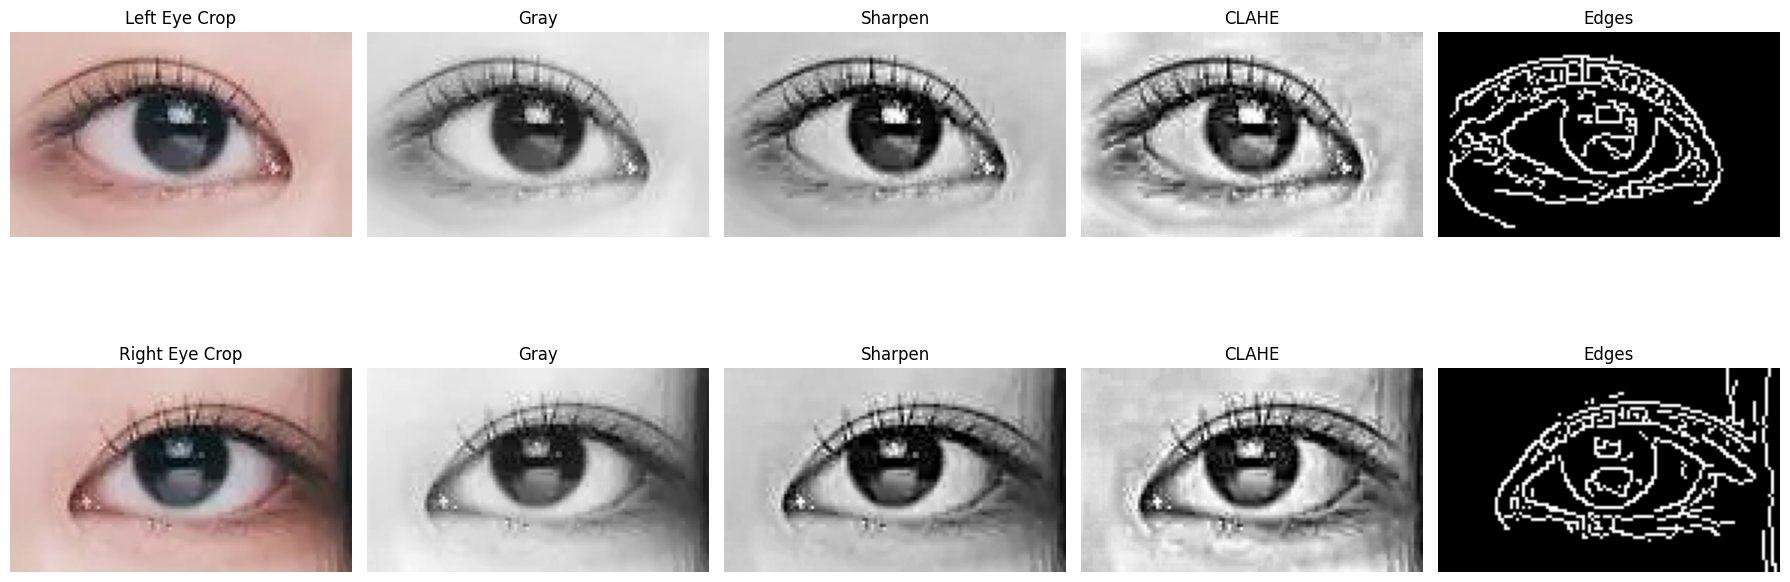

In [ ]:
# ==========================================================
# EYE PREPROCESSING FRAMEWORK
# Crop mắt riêng -> enhance ảnh -> filter -> detect landmarks
# rồi mới dùng để classify dáng mắt / mí mắt
# ==========================================================
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ----------------------------------------------------------
# LOAD MODEL
# ----------------------------------------------------------
model_path = 'face_landmarker_v2_with_blendshapes.task'

# Use CPU delegate (more stable on Apple Silicon)
base_options = python.BaseOptions(
    model_asset_path=model_path,
    delegate=python.BaseOptions.Delegate.CPU
)

options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False
)

face_mesh = vision.FaceLandmarker.create_from_options(options)
print("✓ Model loaded successfully")

# ----------------------------------------------------------
# LOAD IMAGE
# ----------------------------------------------------------
img = cv2.imread("../Photo_PNG/ThanhThu.png")

# Convert to MediaPipe Image format
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

# Use detect() instead of process()
result = face_mesh.detect(mp_image)

if not result.face_landmarks:
    print("No face found")
    exit()

# Get the first face landmarks
face = result.face_landmarks[0]
h, w, _ = img.shape

# ----------------------------------------------------------
# HELPER
# ----------------------------------------------------------
def pt(i):
    return (
        int(face[i].x * w),
        int(face[i].y * h)
    )

# ----------------------------------------------------------
# LEFT EYE LANDMARKS
# ----------------------------------------------------------
LEFT_EYE = [
33,7,163,144,145,153,154,155,
133,173,157,158,159,160,161,246
]

RIGHT_EYE = [
362,382,381,380,374,373,390,249,
263,466,388,387,386,385,384,398
]

# ----------------------------------------------------------
# CROP FUNCTION
# ----------------------------------------------------------
def crop_eye(eye_points, padding=20):
    xs = []
    ys = []
    
    for idx in eye_points:
        x, y = pt(idx)
        xs.append(x)
        ys.append(y)

    x1 = max(min(xs)-padding, 0)
    y1 = max(min(ys)-padding, 0)
    x2 = min(max(xs)+padding, w)
    y2 = min(max(ys)+padding, h)

    roi = img[y1:y2, x1:x2]
    return roi

# ----------------------------------------------------------
# GET EYES
# ----------------------------------------------------------
left_eye = crop_eye(LEFT_EYE)
right_eye = crop_eye(RIGHT_EYE)

# ----------------------------------------------------------
# PREPROCESS FUNCTION
# ----------------------------------------------------------
def preprocess(roi):
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    # sharpen
    blur = cv2.GaussianBlur(gray,(0,0),3)
    sharp = cv2.addWeighted(gray,1.8,blur,-0.8,0)

    # CLAHE contrast
    clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
    enhanced = clahe.apply(sharp)

    # bilateral filter preserve edges
    smooth = cv2.bilateralFilter(enhanced,9,75,75)

    # canny edge
    edges = cv2.Canny(smooth,40,120)

    return gray, sharp, enhanced, smooth, edges

# ----------------------------------------------------------
# PROCESS BOTH EYES
# ----------------------------------------------------------
L_gray, L_sharp, L_enh, L_smooth, L_edges = preprocess(left_eye)
R_gray, R_sharp, R_enh, R_smooth, R_edges = preprocess(right_eye)

# ----------------------------------------------------------
# SHOW FRAMEWORK
# ----------------------------------------------------------
fig, ax = plt.subplots(2,5, figsize=(18,8))

# LEFT
ax[0,0].imshow(cv2.cvtColor(left_eye, cv2.COLOR_BGR2RGB))
ax[0,0].set_title("Left Eye Crop")

ax[0,1].imshow(L_gray,cmap='gray')
ax[0,1].set_title("Gray")

ax[0,2].imshow(L_sharp,cmap='gray')
ax[0,2].set_title("Sharpen")

ax[0,3].imshow(L_enh,cmap='gray')
ax[0,3].set_title("CLAHE")

ax[0,4].imshow(L_edges,cmap='gray')
ax[0,4].set_title("Edges")

# RIGHT
ax[1,0].imshow(cv2.cvtColor(right_eye, cv2.COLOR_BGR2RGB))
ax[1,0].set_title("Right Eye Crop")

ax[1,1].imshow(R_gray,cmap='gray')
ax[1,1].set_title("Gray")

ax[1,2].imshow(R_sharp,cmap='gray')
ax[1,2].set_title("Sharpen")

ax[1,3].imshow(R_enh,cmap='gray')
ax[1,3].set_title("CLAHE")

ax[1,4].imshow(R_edges,cmap='gray')
ax[1,4].set_title("Edges")

for row in ax:
    for col in row:
        col.axis("off")

plt.tight_layout()
plt.show()

# Don't forget to close
face_mesh.close()

W0000 00:00:1777910827.418408 5079958 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1777910827.458816 5079958 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1777910827.465606 5079969 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1777910827.475695 5079969 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


========== RESULT ==========
- Mắt tròn
- Mắt xếch
- Hai mí rõ


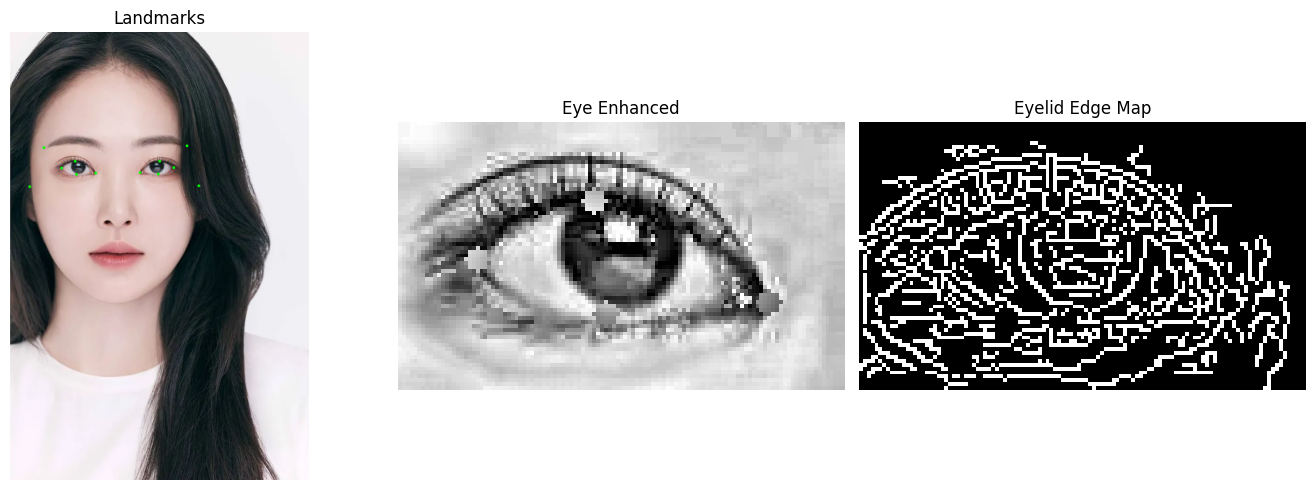

In [4]:
# ==========================================================
# dùng preprocessing frame + geometry + texture analysis
# Detect:
# mắt xếch / mắt sụp / mắt tròn / mắt hạnh nhân
# mắt gần nhau / mắt xa nhau
# mắt một mí / mí lót / hai mí rõ
# mắt lồi nhẹ
# ==========================================================

import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import math
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ----------------------------------------------------------
# MODEL
# ----------------------------------------------------------
model_path = 'face_landmarker_v2_with_blendshapes.task'

# Use CPU delegate (more stable on Apple Silicon)
base_options = python.BaseOptions(
    model_asset_path=model_path,
    delegate=python.BaseOptions.Delegate.CPU
)

options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False
)

face_mesh = vision.FaceLandmarker.create_from_options(options)

# ----------------------------------------------------------
# IMAGE
# ----------------------------------------------------------
img_path = "../Photo_PNG/ThanhThu.png"
img = cv2.imread(img_path)

if img is None:
    print("Cannot read image")
    exit()

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
result = face_mesh.detect(mp_image)

if not result.face_landmarks:
    print("No face found")
    exit()

face = result.face_landmarks[0]
h, w, _ = img.shape

# ----------------------------------------------------------
# HELPERS
# ----------------------------------------------------------
def pt(i):
    return np.array([
        int(face[i].x * w),
        int(face[i].y * h)
    ])

def dist(a,b):
    return np.linalg.norm(a-b)

# ----------------------------------------------------------
# IMPORTANT POINTS
# ----------------------------------------------------------
left_outer = pt(33)
left_inner = pt(133)
left_top   = pt(159)
left_bot   = pt(145)

right_inner = pt(362)
right_outer = pt(263)
right_top   = pt(386)
right_bot   = pt(374)

face_left  = pt(234)
face_right = pt(454)

brow_left = pt(70)
brow_right = pt(300)

# ----------------------------------------------------------
# DRAW
# ----------------------------------------------------------
draw_pts = [33,133,159,145,362,263,386,374,70,300,234,454]

for i in draw_pts:
    x,y = pt(i)
    cv2.circle(img,(x,y),3,(0,255,0),-1)

# ----------------------------------------------------------
# PREPROCESS EYE ROI
# ----------------------------------------------------------
LEFT_EYE = [
33,7,163,144,145,153,154,155,
133,173,157,158,159,160,161,246
]

def crop_eye(points, pad=20):

    xs=[]
    ys=[]

    for p in points:
        x,y = pt(p)
        xs.append(x)
        ys.append(y)

    x1=max(min(xs)-pad,0)
    y1=max(min(ys)-pad,0)
    x2=min(max(xs)+pad,w)
    y2=min(max(ys)+pad,h)

    return img[y1:y2, x1:x2]

eye_roi = crop_eye(LEFT_EYE)

gray = cv2.cvtColor(eye_roi, cv2.COLOR_BGR2GRAY)

# sharpen
blur = cv2.GaussianBlur(gray,(0,0),3)
sharp = cv2.addWeighted(gray,1.8,blur,-0.8,0)

# CLAHE
clahe = cv2.createCLAHE(2.0,(8,8))
enhanced = clahe.apply(sharp)

# edge
edges = cv2.Canny(enhanced,40,120)

# ----------------------------------------------------------
# GEOMETRY FEATURES
# ----------------------------------------------------------
left_w = dist(left_outer,left_inner)
left_h = dist(left_top,left_bot)

right_w = dist(right_outer,right_inner)
right_h = dist(right_top,right_bot)

eye_width = (left_w + right_w)/2
eye_height = (left_h + right_h)/2

ratio = eye_height / eye_width

fw = dist(face_left, face_right)

eye_gap = dist(left_inner, right_inner)
gap_ratio = eye_gap / fw

tilt = left_outer[1] - left_inner[1]

# ----------------------------------------------------------
# TEXTURE FEATURE FOR EYELID
# ----------------------------------------------------------
# tìm edge ngang vùng nửa trên mắt
upper_half = edges[:edges.shape[0]//2, :]

horizontal_score = np.sum(upper_half > 0)

# ----------------------------------------------------------
# RESULT
# ----------------------------------------------------------
results = []

# shape
if ratio > 0.36:
    results.append("Mắt tròn")
elif ratio < 0.26:
    results.append("Mắt hạnh nhân")
else:
    results.append("Mắt cân đối")

# tilt
if tilt < -4:
    results.append("Mắt xếch")
elif tilt > 4:
    results.append("Mắt sụp")

# spacing
if gap_ratio < 0.22:
    results.append("Mắt gần nhau")
elif gap_ratio > 0.30:
    results.append("Mắt xa nhau")

# eyelid detection upgraded
if horizontal_score > 220:
    results.append("Hai mí rõ")
elif horizontal_score > 130:
    results.append("Mí lót")
else:
    results.append("Một mí / mí ẩn")

# bulging
if ratio > 0.40 and eye_height > 18:
    results.append("Mắt lồi nhẹ")

# ----------------------------------------------------------
# PRINT
# ----------------------------------------------------------
print("========== RESULT ==========")
for r in results:
    print("-", r)

# ----------------------------------------------------------
# SHOW
# ----------------------------------------------------------
fig, ax = plt.subplots(1,3, figsize=(14,5))

ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Landmarks")

ax[1].imshow(enhanced,cmap="gray")
ax[1].set_title("Eye Enhanced")

ax[2].imshow(edges,cmap="gray")
ax[2].set_title("Eyelid Edge Map")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

# Don't forget to close
face_mesh.close()

I0000 00:00:1777630932.543774       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4


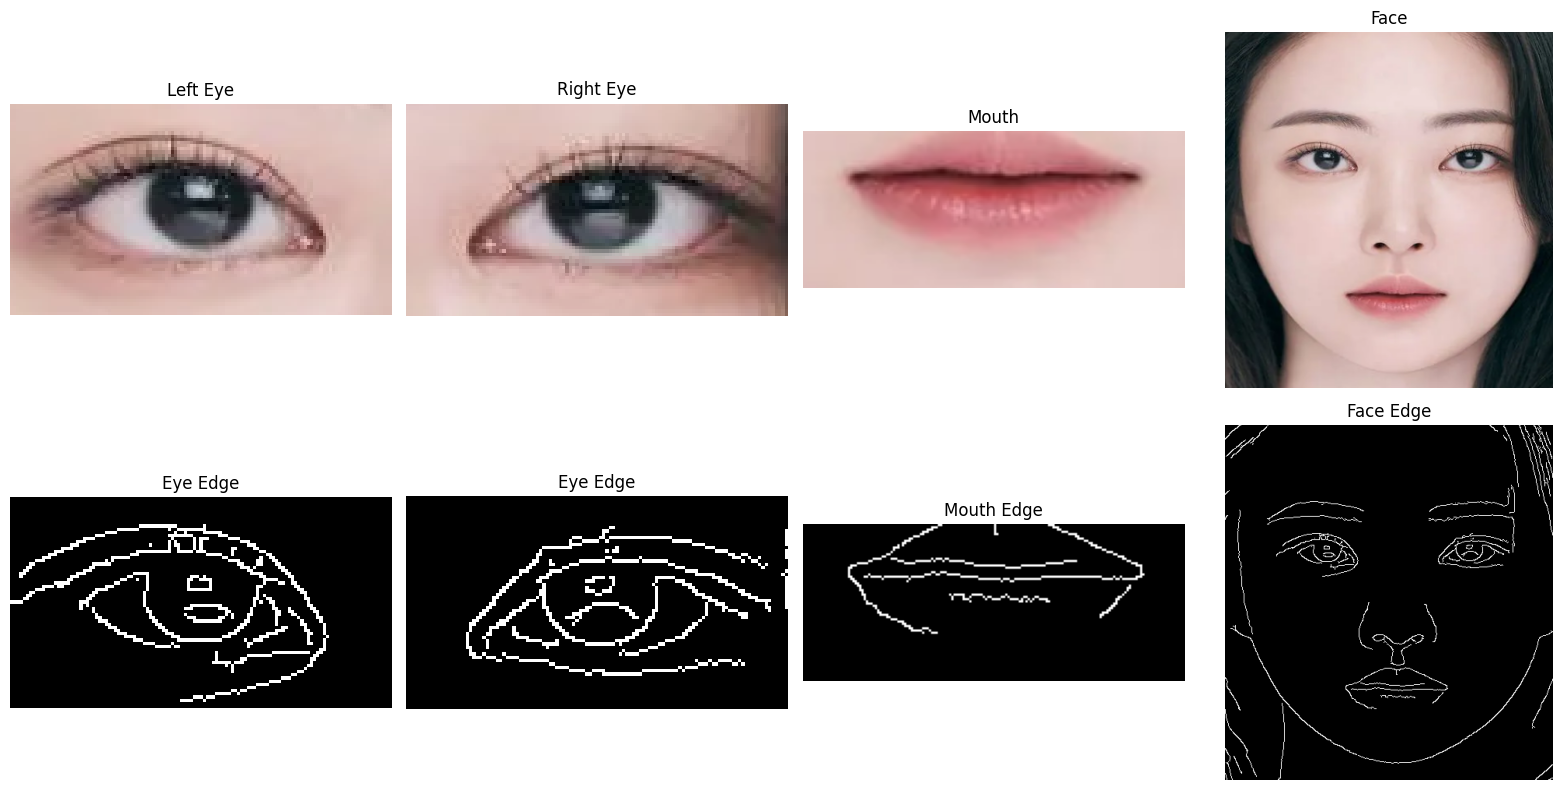

In [258]:

img = cv2.imread("../Photo_PNG/ThanhThu.png")

img = cv2.resize(img,(700,900))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# contrast
clahe = cv2.createCLAHE(2.0,(8,8))
gray = clahe.apply(gray)

# smooth
gray = cv2.bilateralFilter(gray,9,75,75)

# sharpen
blur = cv2.GaussianBlur(gray,(0,0),3)
gray = cv2.addWeighted(gray,1.6,blur,-0.6,0)

# edge map global
edges = cv2.Canny(gray,40,120)

# convert back RGB for mediapipe
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ==================================================
# FACEMESH
# ==================================================
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True
)

result = face_mesh.process(rgb)

face = result.multi_face_landmarks[0]

h,w,_ = img.shape

def pt(i):
    return (
        int(face.landmark[i].x*w),
        int(face.landmark[i].y*h)
    )

# ==================================================
# GENERIC ROI CROP
# ==================================================
def crop_from_points(points,pad=20):

    xs=[]
    ys=[]

    for i in points:
        x,y = pt(i)
        xs.append(x)
        ys.append(y)

    x1=max(min(xs)-pad,0)
    y1=max(min(ys)-pad,0)

    x2=min(max(xs)+pad,w)
    y2=min(max(ys)+pad,h)

    roi_img = img[y1:y2,x1:x2]
    roi_gray = gray[y1:y2,x1:x2]
    roi_edge = edges[y1:y2,x1:x2]

    return roi_img, roi_gray, roi_edge

# ==================================================
# REGIONS
# ==================================================
LEFT_EYE = [33,7,163,144,145,153,154,155,133,173,157,158,159,160,161,246]

RIGHT_EYE = [362,382,381,380,374,373,390,249,263,466,388,387,386,385,384,398]

MOUTH = [61,146,91,181,84,17,314,405,321,375,291]

FACE = [10,338,297,332,284,251,389,356,454,323,361,288,397,365,379,378,400,377,152,148,176,149,150,136,172,58,132,93,234,127,162,21,54,103,67,109]

# ==================================================
# CROP ALL
# ==================================================
left_eye_img,left_eye_gray,left_eye_edge = crop_from_points(LEFT_EYE)
right_eye_img,right_eye_gray,right_eye_edge = crop_from_points(RIGHT_EYE)
mouth_img,mouth_gray,mouth_edge = crop_from_points(MOUTH)
face_img,face_gray,face_edge = crop_from_points(FACE)

# ==================================================
# SHOW
# ==================================================
fig,ax = plt.subplots(2,4,figsize=(16,8))

ax[0,0].imshow(cv2.cvtColor(left_eye_img,cv2.COLOR_BGR2RGB))
ax[0,0].set_title("Left Eye")

ax[0,1].imshow(cv2.cvtColor(right_eye_img,cv2.COLOR_BGR2RGB))
ax[0,1].set_title("Right Eye")

ax[0,2].imshow(cv2.cvtColor(mouth_img,cv2.COLOR_BGR2RGB))
ax[0,2].set_title("Mouth")

ax[0,3].imshow(cv2.cvtColor(face_img,cv2.COLOR_BGR2RGB))
ax[0,3].set_title("Face")

ax[1,0].imshow(left_eye_edge,cmap='gray')
ax[1,0].set_title("Eye Edge")

ax[1,1].imshow(right_eye_edge,cmap='gray')
ax[1,1].set_title("Eye Edge")

ax[1,2].imshow(mouth_edge,cmap='gray')
ax[1,2].set_title("Mouth Edge")

ax[1,3].imshow(face_edge,cmap='gray')
ax[1,3].set_title("Face Edge")

for row in ax:
    for col in row:
        col.axis("off")

plt.tight_layout()
plt.show()

========== FACE RESULT ==========
Detected Shape: Mặt kim cương
---------------------------------
Face Length: 56
Forehead Width: 77
Cheek Width: 102
Jaw Width: 46
---------------------------------
Length Ratio: 0.55
Jaw Ratio: 0.45
Forehead Ratio: 0.75
---------------------------------
Jawline: Jawline V-line
Cheekbone: Gò má nổi bật
Symmetry: Khá cân đối


I0000 00:00:1777630932.831981       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4


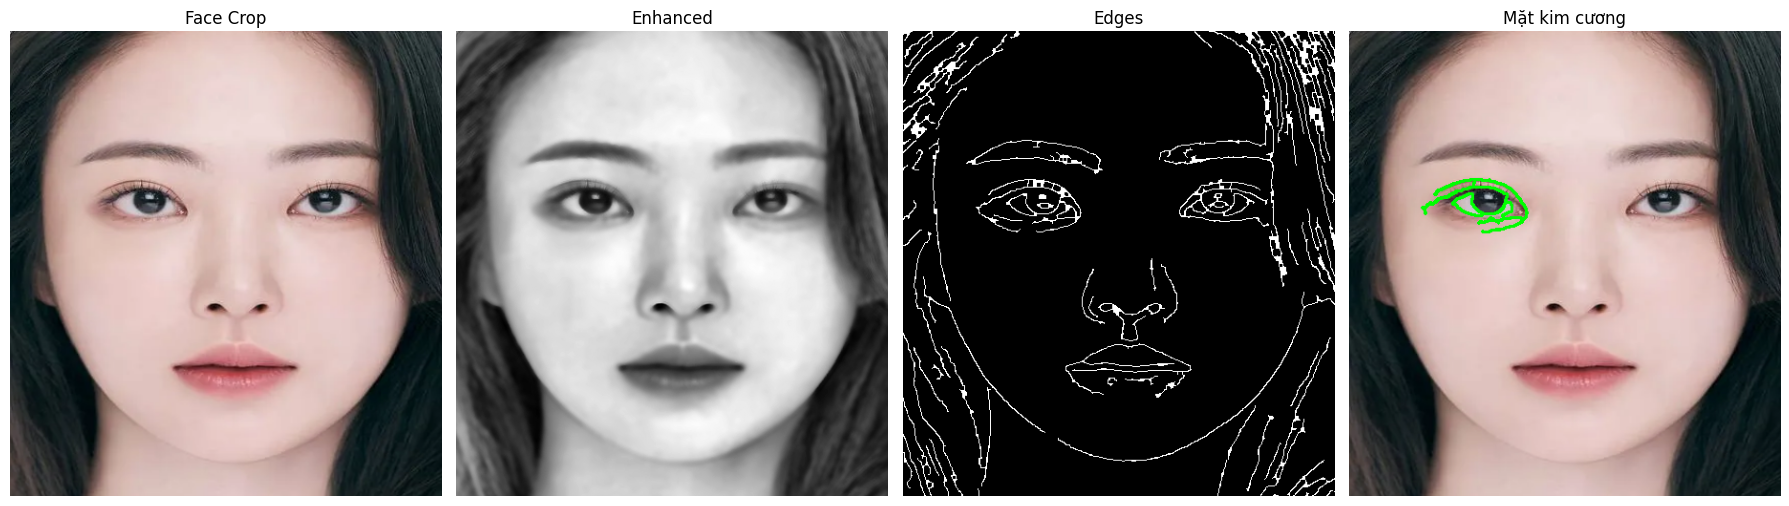

In [ ]:
# ==========================================================
# Detect:
# - Oval
# - Round
# - Square
# - Long
# - Heart
# - Triangle
# - Diamond
#
# Bonus:
# - Jawline
# - Cheekbone prominence
# - Symmetry
# ==========================================================

import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------
IMG_PATH = "../Photo_PNG/ThanhThu.png"

# ----------------------------------------------------------
# LOAD IMAGE
# ----------------------------------------------------------
img = cv2.imread(IMG_PATH)

if img is None:
    print("Cannot read image.")
    exit()

img = cv2.resize(img, (700,900))
raw = img.copy()

# ----------------------------------------------------------
# GLOBAL PREPROCESS
# ----------------------------------------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
gray = clahe.apply(gray)

gray = cv2.bilateralFilter(gray,9,75,75)

blur = cv2.GaussianBlur(gray,(0,0),3)
gray = cv2.addWeighted(gray,1.5,blur,-0.5,0)

# softer edge thresholds
edges = cv2.Canny(gray,20,80)

kernel = np.ones((3,3),np.uint8)
edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

# ----------------------------------------------------------
# MEDIAPIPE
# ----------------------------------------------------------
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True
)

rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
result = face_mesh.process(rgb)

if not result.multi_face_landmarks:
    print("No face detected.")
    exit()

face = result.multi_face_landmarks[0]
h,w,_ = raw.shape
def pt(i):
    return np.array([
        int(face.landmark[i].x*w),
        int(face.landmark[i].y*h)
    ])

FACE_POINTS = [
10,338,297,332,284,251,389,356,454,
323,361,288,397,365,379,378,400,377,
152,148,176,149,150,136,172,58,132,
93,234,127,162,21,54,103,67,109
]

xs=[]
ys=[]

for i in FACE_POINTS:
    x,y = pt(i)
    xs.append(x)
    ys.append(y)

pad = 35

x1=max(min(xs)-pad,0)
x2=min(max(xs)+pad,w)

y1=max(min(ys)-pad,0)
y2=min(max(ys)+pad,h)

face_crop = raw[y1:y2, x1:x2]
face_gray = gray[y1:y2, x1:x2]
face_edge = edges[y1:y2, x1:x2]

# ----------------------------------------------------------
# FIND CONTOURS
# ----------------------------------------------------------
contours,_ = cv2.findContours(
    face_edge,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

if len(contours) == 0:
    print("No contour found.")
    exit()

# ----------------------------------------------------------
# SMART FILTER CONTOURS
# ----------------------------------------------------------
valid=[]

center_x = face_crop.shape[1] / 2

for c in contours:

    area = cv2.contourArea(c)

    if area < 500:
        continue

    x,y,wc,hc = cv2.boundingRect(c)

    cx = x + wc/2

    # prefer center contours
    if abs(cx - center_x) < face_crop.shape[1]*0.35:
        valid.append(c)

# fallback
if len(valid) == 0:
    largest = max(contours, key=cv2.contourArea)
else:
    largest = max(valid, key=cv2.contourArea)

# ----------------------------------------------------------
# DRAW CONTOUR
# ----------------------------------------------------------
contour_view = face_crop.copy()
cv2.drawContours(contour_view,[largest],-1,(0,255,0),2)

# ----------------------------------------------------------
# BOUNDING RECT
# ----------------------------------------------------------
x,y,wc,hc = cv2.boundingRect(largest)

face_len = hc

# ----------------------------------------------------------
# WIDTH MEASURE FUNCTION
# ----------------------------------------------------------
def width_at_ratio(r):

    yy = int(y + hc*r)

    xs=[]

    for p in largest:
        px,py = p[0]

        if abs(py-yy) < 4:
            xs.append(px)

    if len(xs) < 2:
        return 0

    return max(xs)-min(xs)

forehead_w = width_at_ratio(0.20)
cheek_w    = width_at_ratio(0.45)
jaw_w      = width_at_ratio(0.78)

# fallback widths
if forehead_w == 0: forehead_w = wc*0.82
if cheek_w == 0: cheek_w = wc
if jaw_w == 0: jaw_w = wc*0.76

# ----------------------------------------------------------
# RATIOS
# ----------------------------------------------------------
L = face_len / cheek_w
J = jaw_w / cheek_w
F = forehead_w / cheek_w

# ----------------------------------------------------------
# CLASSIFY SHAPE
# ----------------------------------------------------------
if L > 1.58:
    shape = "Mặt dài"

elif L < 1.30 and J > 0.88:
    shape = "Mặt tròn"

elif L < 1.40 and J > 0.95:
    shape = "Mặt vuông"

elif F > 1.03 and J < 0.84:
    shape = "Mặt trái tim"

elif F < 0.94 and J > 0.95:
    shape = "Mặt tam giác"

elif cheek_w > forehead_w and cheek_w > jaw_w and J < 0.88:
    shape = "Mặt kim cương"

else:
    shape = "Mặt oval"

# ----------------------------------------------------------
# BONUS ANALYSIS
# ----------------------------------------------------------
if J < 0.78:
    jaw = "Jawline V-line"

elif J < 0.92:
    jaw = "Jawline thon"

else:
    jaw = "Jawline rộng"

if cheek_w > forehead_w*1.05 and cheek_w > jaw_w*1.05:
    cheek = "Gò má nổi bật"
else:
    cheek = "Gò má mềm"

# symmetry
left_half = face_crop[:, :face_crop.shape[1]//2]
right_half = cv2.flip(face_crop[:, face_crop.shape[1]//2:],1)

min_w = min(left_half.shape[1], right_half.shape[1])

left_half = left_half[:, :min_w]
right_half = right_half[:, :min_w]

diff = np.mean(np.abs(left_half.astype("float") - right_half.astype("float")))

if diff < 22:
    sym = "Rất cân đối"
elif diff < 35:
    sym = "Khá cân đối"
else:
    sym = "Lệch nhẹ"

# ----------------------------------------------------------
# PRINT
# ----------------------------------------------------------
print("========== FACE RESULT ==========")
print("Detected Shape:", shape)
print("---------------------------------")
print("Face Length:", round(face_len,2))
print("Forehead Width:", round(forehead_w,2))
print("Cheek Width:", round(cheek_w,2))
print("Jaw Width:", round(jaw_w,2))
print("---------------------------------")
print("Length Ratio:", round(L,2))
print("Jaw Ratio:", round(J,2))
print("Forehead Ratio:", round(F,2))
print("---------------------------------")
print("Jawline:", jaw)
print("Cheekbone:", cheek)
print("Symmetry:", sym)

# ----------------------------------------------------------
# SHOW
# ----------------------------------------------------------
fig,ax = plt.subplots(1,4, figsize=(18,7))

ax[0].imshow(cv2.cvtColor(face_crop,cv2.COLOR_BGR2RGB))
ax[0].set_title("Face Crop")

ax[1].imshow(face_gray,cmap='gray')
ax[1].set_title("Enhanced")

ax[2].imshow(face_edge,cmap='gray')
ax[2].set_title("Edges")

ax[3].imshow(cv2.cvtColor(contour_view,cv2.COLOR_BGR2RGB))
ax[3].set_title(shape)

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

========== LIP RESULT ==========
- Môi đầy
- Môi dưới dày hơn
- Viền môi tròn
- Khóe môi ngang
- Màu môi trung tính
- Texture mịn
- Môi rất cân đối
--------------------------------
Lip Ratio: 0.377
Top/Bottom: 0.656
Bow Depth: 3.0
HSV: 49.7 64.2 213.0
Texture: 38.98
Symmetry: 6.87


I0000 00:00:1777630939.193074       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4


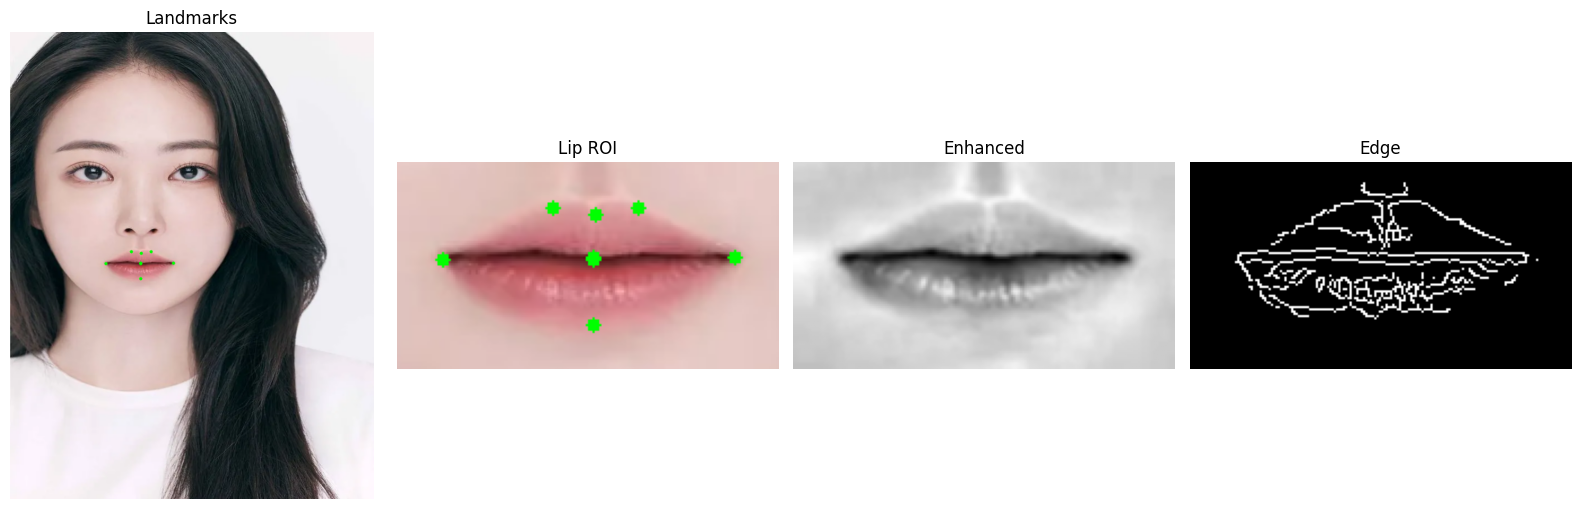

In [261]:
# ==========================================================
# Detect:
# - môi mỏng / vừa / đầy
# - môi trên dày / môi dưới dày / cân đối
# - môi trái tim / cupid bow rõ
# - khóe môi hướng lên / xuống / ngang
# - đối xứng môi
# - màu môi nhạt / hồng / đậm / thâm nhẹ
# - texture khô / mịn
# ==========================================================

import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------
IMG_PATH = "../Photo_PNG/ThanhThu.png"

# ----------------------------------------------------------
# LOAD IMAGE
# ----------------------------------------------------------
img = cv2.imread(IMG_PATH)

if img is None:
    print("Cannot read image")
    exit()

img = cv2.resize(img,(700,900))
raw = img.copy()

# ----------------------------------------------------------
# GLOBAL PREPROCESS
# ----------------------------------------------------------
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

clahe = cv2.createCLAHE(2.0,(8,8))
gray = clahe.apply(gray)

gray = cv2.bilateralFilter(gray,9,75,75)

blur = cv2.GaussianBlur(gray,(0,0),3)
gray = cv2.addWeighted(gray,1.4,blur,-0.4,0)

# ----------------------------------------------------------
# MEDIAPIPE
# ----------------------------------------------------------
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True
)

rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
result = face_mesh.process(rgb)

if not result.multi_face_landmarks:
    print("No face found")
    exit()

face = result.multi_face_landmarks[0]
h,w,_ = raw.shape

# ----------------------------------------------------------
# HELPERS
# ----------------------------------------------------------
def pt(i):
    return np.array([
        int(face.landmark[i].x*w),
        int(face.landmark[i].y*h)
    ])

def dist(a,b):
    return np.linalg.norm(a-b)

# ----------------------------------------------------------
# LIP LANDMARKS
# ----------------------------------------------------------
left_corner  = pt(61)
right_corner = pt(291)

top_outer    = pt(0)
bottom_outer = pt(17)

top_inner    = pt(13)
bottom_inner = pt(14)

left_bow  = pt(37)
right_bow = pt(267)

# ROI points
LIPS = [
61,146,91,181,84,17,314,405,321,375,291,
0,37,39,40,185,267,269,270,409
]

# ----------------------------------------------------------
# CROP ROI
# ----------------------------------------------------------
xs=[]
ys=[]

for i in LIPS:
    x,y = pt(i)
    xs.append(x)
    ys.append(y)

pad = 20

x1=max(min(xs)-pad,0)
x2=min(max(xs)+pad,w)

y1=max(min(ys)-pad,0)
y2=min(max(ys)+pad,h)

lip_roi = raw[y1:y2,x1:x2]

# ----------------------------------------------------------
# LOCAL REFINE ROI
# ----------------------------------------------------------
lip_gray = cv2.cvtColor(lip_roi, cv2.COLOR_BGR2GRAY)

clahe2 = cv2.createCLAHE(2.0,(8,8))
lip_gray = clahe2.apply(lip_gray)

lip_gray = cv2.GaussianBlur(lip_gray,(3,3),0)

lip_edge = cv2.Canny(lip_gray,25,90)

# ----------------------------------------------------------
# GEOMETRY
# ----------------------------------------------------------
mouth_width = dist(left_corner,right_corner)

upper_h = dist(top_outer,top_inner)
lower_h = dist(bottom_outer,bottom_inner)

lip_h = dist(top_outer,bottom_outer)

ratio = lip_h / mouth_width
tb_ratio = upper_h / (lower_h + 1e-6)

# cupid bow
bow_depth = abs((left_bow[1]+right_bow[1])/2 - top_outer[1])

# corner angle
corner_avg = (left_corner[1]+right_corner[1])/2

tilt = corner_avg - top_outer[1]

# ----------------------------------------------------------
# COLOR ANALYSIS
# ----------------------------------------------------------
hsv = cv2.cvtColor(lip_roi, cv2.COLOR_BGR2HSV)

mean_h = np.mean(hsv[:,:,0])
mean_s = np.mean(hsv[:,:,1])
mean_v = np.mean(hsv[:,:,2])

# ----------------------------------------------------------
# TEXTURE
# ----------------------------------------------------------
texture = np.std(lip_gray)

# ----------------------------------------------------------
# SYMMETRY
# ----------------------------------------------------------
left_half = lip_roi[:, :lip_roi.shape[1]//2]
right_half = cv2.flip(lip_roi[:, lip_roi.shape[1]//2:],1)

min_w = min(left_half.shape[1], right_half.shape[1])

left_half = left_half[:, :min_w]
right_half = right_half[:, :min_w]

sym_diff = np.mean(np.abs(left_half.astype("float") - right_half.astype("float")))

# ----------------------------------------------------------
# CLASSIFY
# ----------------------------------------------------------
results=[]

# fullness
if ratio < 0.22:
    results.append("Môi mỏng")
elif ratio < 0.30:
    results.append("Môi vừa")
else:
    results.append("Môi đầy")

# top bottom
if tb_ratio > 1.15:
    results.append("Môi trên dày hơn")
elif tb_ratio < 0.85:
    results.append("Môi dưới dày hơn")
else:
    results.append("Hai môi cân đối")

# cupid bow
if bow_depth > 7:
    results.append("Môi trái tim / Cupid bow rõ")
elif bow_depth > 4:
    results.append("Cupid bow nhẹ")
else:
    results.append("Viền môi tròn")

# corner
if tilt < 18:
    results.append("Khóe môi hướng lên")
elif tilt > 28:
    results.append("Khóe môi hướng xuống")
else:
    results.append("Khóe môi ngang")

# color
if mean_v < 95:
    results.append("Môi thâm nhẹ / tối màu")
elif mean_s < 45:
    results.append("Màu môi nhạt")
elif mean_h < 12:
    results.append("Môi hồng / đỏ")
else:
    results.append("Màu môi trung tính")

# texture
if texture > 42:
    results.append("Texture khô / nhiều rãnh")
else:
    results.append("Texture mịn")

# symmetry
if sym_diff < 18:
    results.append("Môi rất cân đối")
elif sym_diff < 30:
    results.append("Môi khá cân đối")
else:
    results.append("Môi lệch nhẹ")

# ----------------------------------------------------------
# PRINT
# ----------------------------------------------------------
print("========== LIP RESULT ==========")
for r in results:
    print("-", r)

print("--------------------------------")
print("Lip Ratio:", round(ratio,3))
print("Top/Bottom:", round(tb_ratio,3))
print("Bow Depth:", round(float(bow_depth),2))
print("HSV:", round(mean_h,1), round(mean_s,1), round(mean_v,1))
print("Texture:", round(float(texture),2))
print("Symmetry:", round(float(sym_diff),2))

# ----------------------------------------------------------
# DRAW
# ----------------------------------------------------------
for i in [61,291,0,17,13,14,37,267]:
    x,y = pt(i)
    cv2.circle(raw,(x,y),3,(0,255,0),-1)

# ----------------------------------------------------------
# SHOW
# ----------------------------------------------------------
fig,ax = plt.subplots(1,4, figsize=(16,5))

ax[0].imshow(cv2.cvtColor(raw,cv2.COLOR_BGR2RGB))
ax[0].set_title("Landmarks")

ax[1].imshow(cv2.cvtColor(lip_roi,cv2.COLOR_BGR2RGB))
ax[1].set_title("Lip ROI")

ax[2].imshow(lip_gray,cmap='gray')
ax[2].set_title("Enhanced")

ax[3].imshow(lip_edge,cmap='gray')
ax[3].set_title("Edge")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()